<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/3_T%C3%A9cnicas_de_remuestreo_Jackknife.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**NOMBRE: FLORENCIO FLORENCIO MIRIAM LIZETH**

<span style="color:purple;"> **Objetivo:**</span>
El objetivo de este ejercicio es utilizar el método Jackknife para analizar la estabilidad de la media de los tiempos de entrega a partir de una muestra de datos. Para ello, se generan múltiples estimaciones de la media eliminando una observación diferente en cada iteración. A partir de estas estimaciones se evalúa la variabilidad del estimador, se calcula su error estándar y se construye un intervalo de confianza del $95\%$. Este procedimiento permite estudiar la precisión de la media sin necesidad de asumir una distribución probabilística específica para los datos observados.

#  <span style="color:purple;">**Jackknife**</span>

Tenemos una muestra de $n$ datos, En esta técnica eliminamos uno de los datos para obtener $n$ muestras de tamaño $n-1$.

Para cada muestra calculamos el estadístico $\hat{θ}_i$ y luego obtemos el promedio del **Jackknife**:

$$
θ=\frac{1}{n} ∑_{i=1}^n \hat{θ}_i
$$

Y la varianza
$$
var_{Jac}=\frac{n-1}{n} ∑_{i=1}^n (θ-\hat{θ}_i)^2
$$

<span style="color:green;">**Ejercicio:**</span> **Esta es una muestra aleatoria de 12 tiempos de entrega:**

$$
35,42,38,40,45,37,39,41,44,36,43,40
$$

**Instrucciones:**

1. Use la muestra original de 12 observaciones y aplique Jackknife

2. Calcular la **var**

3. Al final:

* Clacule la desviación estándar.
* Determine los porcentiles $2.5\%$ y $97.5\%$ para construir el  intervalo de confianza $B$ del $95\%$

**Este metodo consite en crear muestras $n$ de tamaño $n-1$; es decir creamos $12$ muestras de tamaño $11$.**

In [14]:
#Importación de librerías
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [15]:
datos = np.array([         #Datos de la muestra
    35, 42, 38, 40, 45, 37,
    39, 41, 44, 36, 43, 40
])

In [16]:
datos # Datos proporcionados por el ejercicio

array([35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40])

In [17]:
n = len(datos)#contar lo datos

In [18]:
n

12

 **Generamos las muestras Jackknife de tamaño** $$11$$

In [19]:
# Estimadores
estimadores = []

for i in range(n):

    # Eliminar la observación i
    muestra_jack = np.delete(datos, i)

    # Media de la muestra reducida
    theta_i = np.mean(muestra_jack)

    estimadores.append(theta_i)

estimadores = np.array(estimadores)

# Crear tabla
tabla_jackknife = pd.DataFrame({
    'Observación eliminada': np.arange(1, n+1),
    'Valor eliminado': datos,
    'Media Jackknife': estimadores
})

print(tabla_jackknife)

    Observación eliminada  Valor eliminado  Media Jackknife
0                       1               35        40.454545
1                       2               42        39.818182
2                       3               38        40.181818
3                       4               40        40.000000
4                       5               45        39.545455
5                       6               37        40.272727
6                       7               39        40.090909
7                       8               41        39.909091
8                       9               44        39.636364
9                      10               36        40.363636
10                     11               43        39.727273
11                     12               40        40.000000


### Calculamos el **Promedio Jackknife**

$$
θ=\frac{1}{12} ∑_{i=1}^{12} \hat{θ}_i
$$

In [20]:
theta_jack = np.mean(estimadores)
theta_jack

np.float64(40.0)

**El promedio** $$\bar{X}=40$$



In [21]:
#Varianza Jackknife
var_jack = ((n - 1)/n) * np.sum(
    (estimadores - theta_jack)**2
)
var_jack

np.float64(0.8333333333333355)

**La varianza $σ^2=0.8333$**


In [22]:
# Desviacion estandar Jackknife
desv_jack = np.sqrt(var_jack)
desv_jack

np.float64(0.912870929175278)

In [23]:
# Percentiles e intervalo de confianza*
p025 = np.percentile(estimadores, 2.5)
p975 = np.percentile(estimadores, 97.5)

**Finalmente Obteniendo los resultados**

In [24]:
#Imprimen los resultados
tabla_resumen = pd.DataFrame({
    "n": [n],
    "Media Jackknife": [theta_jack],
    "Varianza": [var_jack],
    "Desv. Estándar": [desv_jack],
    "P2.5%": [p025],
    "P97.5%": [p975],
    "IC 95%": [f"({p025:.4f}, {p975:.4f})"]
})

display(tabla_resumen)

,n,Media Jackknife,Varianza,Desv. Estándar,P2.5%,P97.5%,IC 95%
0,12,40.0,0.833333,0.912871,39.570455,40.429545,"(39.5705, 40.4295)"


**Mostrando los estimadores Jackknife los cuales seran 12**

In [25]:
for i, valor in enumerate(estimadores, start=1):
    print(f"θ_{i:2d} = {valor:.6f}")

θ_ 1 = 40.454545
θ_ 2 = 39.818182
θ_ 3 = 40.181818
θ_ 4 = 40.000000
θ_ 5 = 39.545455
θ_ 6 = 40.272727
θ_ 7 = 40.090909
θ_ 8 = 39.909091
θ_ 9 = 39.636364
θ_10 = 40.363636
θ_11 = 39.727273
θ_12 = 40.000000


A continuación mostramos una Gráfica de los <span style="color:teal;"> estimadores de **Jackknife**</span>

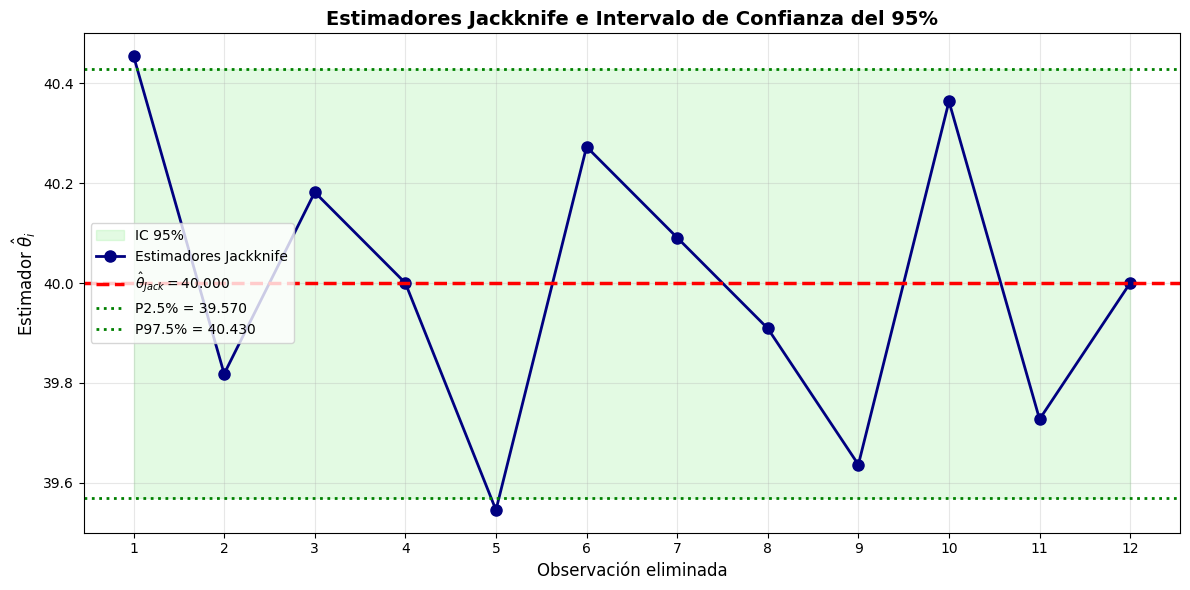

In [26]:
plt.figure(figsize=(12,6))

x = np.arange(1, n+1)

# Banda del intervalo de confianza
plt.fill_between(
    x,
    p025,
    p975,
    alpha=0.25,
    color='lightgreen',
    label='IC 95%'
)

# Estimadores Jackknife
plt.plot(
    x,
    estimadores,
    marker='o',
    markersize=8,
    linewidth=2,
    color='navy',
    label='Estimadores Jackknife'
)

# Promedio Jackknife
plt.axhline(
    theta_jack,
    color='red',
    linestyle='--',
    linewidth=2.5,
    label=fr'$\hat{{\theta}}_{{Jack}}={theta_jack:.3f}$'
)

# Límite inferior
plt.axhline(
    p025,
    color='green',
    linestyle=':',
    linewidth=2,
    label=f'P2.5% = {p025:.3f}'
)

# Límite superior
plt.axhline(
    p975,
    color='green',
    linestyle=':',
    linewidth=2,
    label=f'P97.5% = {p975:.3f}'
)

plt.xticks(x)

plt.xlabel('Observación eliminada', fontsize=12)
plt.ylabel(r'Estimador $\hat{\theta}_i$', fontsize=12)

plt.title(
    'Estimadores Jackknife e Intervalo de Confianza del 95%',
    fontsize=14,
    fontweight='bold'
)

plt.grid(alpha=0.3)
plt.legend(loc='best')

plt.tight_layout()
plt.show()

<span style="color:teal;">**Interpretación**</span>

Se observa que todos los estimadores Jackknife oscilan alrededor del valor de $40$, que corresponde al promedio Jackknife (línea roja punteada). Las diferencias entre las estimaciones son pequeñas, ya que los valores se encuentran aproximadamente entre $39.55$ y $40.45$.

Los puntos más alejados del promedio aparecen cuando se eliminan las observaciones $1$, $5$ y $10$. Sin embargo, incluso en estos casos, la variación respecto al promedio sigue siendo reducida. Esto indica que ninguna observación individual tiene una influencia excesiva sobre la estimación de la media.


La región sombreada en verde representa el intervalo de confianza del $95\%$, delimitado por los percentiles:
$$P_{2.5 \% }= 39.570$$
$$P_{97.5\%} = 40.430.$$

La mayoría de las estimaciones se encuentran dentro de esta banda, mientras que unas pocas quedan ligeramente por encima o por debajo de los límites. Este comportamiento es normal debido a la variabilidad inherente al procedimiento Jackknife y no sugiere la presencia de valores atípicos o altamente influyentes.

## <span style="color:green;"> **Conclusión**</span>

Al aplicar el método Jackknife se pudo observar cómo cambia la media de los tiempos de entrega cuando se elimina una observación de la muestra a la vez. Los resultados mostraron que las distintas medias calculadas fueron muy similares entre sí, lo que indica que la estimación es bastante estable y que ningún dato individual tiene un impacto excesivo sobre el valor final de la media.

Además, el análisis permitió obtener una medida de la variabilidad asociada a esta estimación mediante la varianza, la desviación estándar y el intervalo de confianza del 95%. El hecho de que dicho intervalo sea relativamente pequeño sugiere que existe una buena precisión en la estimación del tiempo promedio de entrega y que los datos presentan un comportamiento consistente alrededor de ese valor.

Más allá de los resultados numéricos, este ejercicio permitió comprobar que la media es una medida representativa para este conjunto de datos. También mostró cómo el método Jackknife puede utilizarse para evaluar la confiabilidad de una estimación de manera sencilla, aprovechando únicamente la información contenida en la muestra. En este caso, los resultados obtenidos generan confianza en que el tiempo promedio calculado describe adecuadamente el comportamiento general de los tiempos de entrega observados.